Step 1: Import Libraries & Generate a Dataset

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Generate a synthetic dataset
# 200 rows, 2 features (Packet Size & Request Frequency), predicting 2 classes (Safe vs Malicious)
X_raw, y_raw = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=42,
)

# Convert it into a clean Pandas DataFrame so you can see it easily
df = pd.DataFrame(X_raw, columns=["Packet_Size", "Request_Frequency"])
df["Target_Class"] = y_raw

# Inspect the first 5 rows of our brand new dataset
print("Dataset created successfully!")
print(df.head())

Dataset created successfully!
   Packet_Size  Request_Frequency  Target_Class
0     1.689767          -1.408241             1
1     1.530287          -1.459848             1
2    -1.175042          -1.447633             0
3    -2.585395           0.963532             0
4     1.372246           0.440695             1


step 2 : Separate and Split the Dataset

In [2]:
# 1. Separate Features (X) from Target Labels (y)
X = df[["Packet_Size", "Request_Frequency"]]
y = df["Target_Class"]

# 2. Split into 80% Training data and 20% Testing data
# random_state ensures that every time you run this code, it splits exactly the same way
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 160 samples
Testing set size: 40 samples


step 3 : Pre-processing & Normalization

In [3]:
# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data, then transform both training and testing features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Pre-processing complete. Data has been successfully normalized!")

Pre-processing complete. Data has been successfully normalized!


step 4 : Train the Model & View Training Results

In [4]:
# 1. Initialize the KNN model with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# 2. Train the model
knn.fit(X_train_scaled, y_train)
print("Model training complete.\n")

# 3. Calculate and display Training Dataset Accuracy
train_accuracy = knn.score(X_train_scaled, y_train)
print(f"--- Step 4 Result ---")
print(f"Training Dataset Accuracy: {train_accuracy * 100:.2f}%")

Model training complete.

--- Step 4 Result ---
Training Dataset Accuracy: 91.25%


Step 5: Evaluate Testing Results & Find the "Final Fit"

In [5]:
test_accuracy = knn.score(X_test_scaled, y_test)
print(f"--- Step 5 Result ---")
print(f"Testing Dataset Accuracy: {test_accuracy * 100:.2f}%\n")

# 2. Generate detailed predictions and evaluation metrics
predictions = knn.predict(X_test_scaled)

print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nDetailed Performance Classification Report:")
print(classification_report(y_test, predictions))

--- Step 5 Result ---
Testing Dataset Accuracy: 80.00%

Confusion Matrix:
[[15  4]
 [ 4 17]]

Detailed Performance Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        19
           1       0.81      0.81      0.81        21

    accuracy                           0.80        40
   macro avg       0.80      0.80      0.80        40
weighted avg       0.80      0.80      0.80        40



Bonus: Visually Verify the Performance

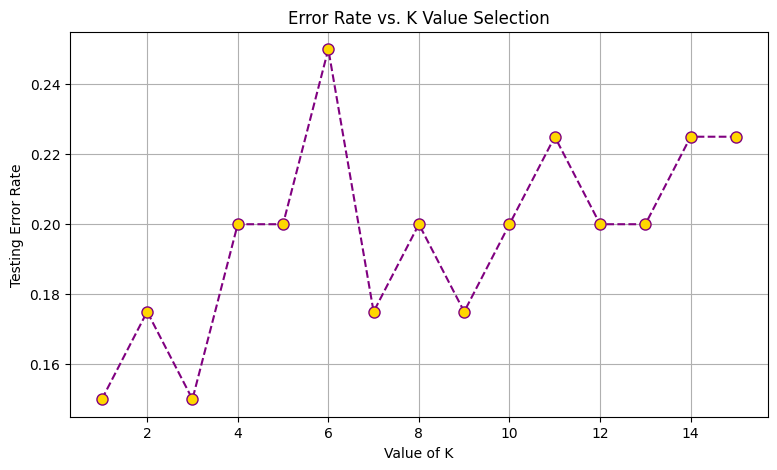

In [6]:
error_rate = []

for i in range(1, 16):
    knn_test = KNeighborsClassifier(n_neighbors=i)
    knn_test.fit(X_train_scaled, y_train)
    pred_i = knn_test.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))

# Create the plot
plt.figure(figsize=(9, 5))
plt.plot(
    range(1, 16),
    error_rate,
    color="purple",
    linestyle="dashed",
    marker="o",
    markerfacecolor="gold",
    markersize=8,
)
plt.title("Error Rate vs. K Value Selection")
plt.xlabel("Value of K")
plt.ylabel("Testing Error Rate")
plt.grid(True)
plt.show()